In [1]:
import pandas as pd
df = pd.read_csv('eia_data.csv')

# Filter to only years 1981 and later
df = df[df['Year'] >= 1981]
df = df[df['State'] != 'US']  

# Add Region
region_mapping = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'WV': 'South', 'AL': 'South', 'KY': 'South',
    'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 
    'TX': 'South', 'DC': 'South',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West'
}

df['Region'] = df['State'].map(region_mapping)

# Add Dominant Energy Source
def get_dominant_energy(row):
    sources = {
        'Coal': row['Coal_Consumption'],
        'Natural Gas': row['NatGas_Consumption'],
        'Nuclear': row['Nuclear_Consumption'],
        'Renewables': row['Renewable_Consumption']
    }
    return max(sources, key=sources.get)

df['Dominant_Energy_Source'] = df.apply(get_dominant_energy, axis=1)

len(df)

2193

In [2]:
import altair as alt
import pandas as pd

# Load data 
df = pd.read_csv('eia_data.csv')
df = df[df['Year'] >= 1981]

# Add Region 
df['Region'] = df['State'].map(region_mapping)

# Calculate average CO2 by region
avg_by_region = df.groupby('Region').agg({
    'CO2_Emissions': 'mean'
}).reset_index()

# Create bar chart
chart2 = alt.Chart(avg_by_region).mark_bar().encode(
    x=alt.X('Region:N', title='Region', sort='-y'),
    y=alt.Y('CO2_Emissions:Q', title='Average CO2 Emissions (Million Metric Tons)'),
    color=alt.Color('Region:N', legend=None),
    tooltip=['Region', alt.Tooltip('CO2_Emissions:Q', format='.2f')]
).properties(
    width=500,
    height=400,
    title='Average CO2 Emissions by Region (1981-2023)'
)

chart2  

/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)

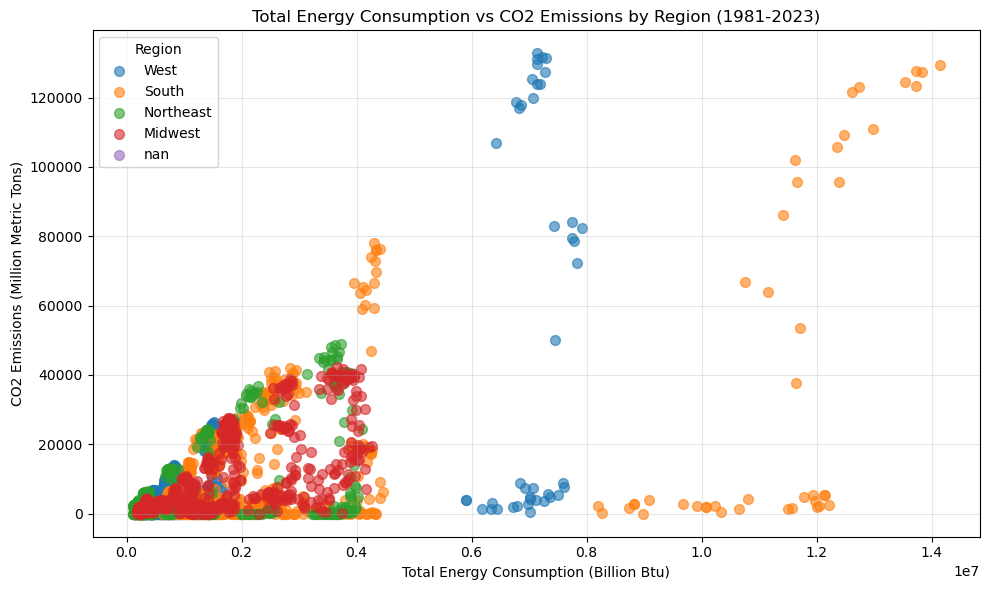

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for region in df['Region'].unique():
    region_data = df[df['Region'] == region]
    plt.scatter(region_data['Total_Energy_Consumption'], 
               region_data['CO2_Emissions'],
               label=region, alpha=0.6, s=50)

plt.xlabel('Total Energy Consumption (Billion Btu)')
plt.ylabel('CO2 Emissions (Million Metric Tons)')
plt.title('Total Energy Consumption vs CO2 Emissions by Region (1981-2023)')
plt.legend(title='Region')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()